# Módulo 2- Aula 2

# Lidando com dados faltantes

In [1]:
import pandas as pd

C:\Users\thali\AppData\Local\Temp\ipykernel_15372\4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
diabetes = pd.read_excel('bases de dados/diabetes.xlsx','in')

In [3]:
diabetes

,pressao arterial,concentraÃ§ao de glicose,insulina,tipo sanguineo,idade,imc,diabetico
0,72.0,148.0,NaN,A,50,33.6,S
1,66.0,85.0,NaN,O,31,26.6,N
2,64.0,183.0,NaN,A,32,23.3,S
3,66.0,89.0,94.0,A,21,28.1,N
4,40.0,137.0,168.0,O,33,43.1,S
...,...,...,...,...,...,...,...
763,76.0,101.0,180.0,A,63,32.9,N
764,70.0,122.0,NaN,A,27,36.8,N
765,72.0,121.0,112.0,O,30,26.2,N
766,60.0,126.0,NaN,NaN,47,30.1,S


In [4]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pressao arterial          733 non-null    float64
 1   concentraÃ§ao de glicose  763 non-null    float64
 2   insulina                  394 non-null    float64
 3   tipo sanguineo            723 non-null    object 
 4   idade                     768 non-null    int64  
 5   imc                       757 non-null    float64
 6   diabetico                 768 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 42.1+ KB


In [5]:
diabetes.isna().sum()

pressao arterial             35
concentraÃ§ao de glicose      5
insulina                    374
tipo sanguineo               45
idade                         0
imc                          11
diabetico                     0
dtype: int64

In [6]:
diabetes['diabetico'].value_counts()

diabetico
N    500
S    268
Name: count, dtype: int64

### Descartando linhas com valores faltantes

In [7]:
diabetes[diabetes['concentraÃ§ao de glicose'].isna() | diabetes['imc'].isna()]

,pressao arterial,concentraÃ§ao de glicose,insulina,tipo sanguineo,idade,imc,diabetico
9,96.0,125.0,NaN,A,54,NaN,S
49,NaN,105.0,NaN,A,24,NaN,N
60,NaN,84.0,NaN,NaN,21,NaN,N
75,48.0,NaN,NaN,A,22,24.7,N
81,NaN,74.0,NaN,A,22,NaN,N
145,75.0,102.0,NaN,A,21,NaN,N
182,74.0,NaN,23.0,O,21,27.7,N
342,68.0,NaN,NaN,A,22,32.0,N
349,80.0,NaN,NaN,O,37,41.0,S
371,64.0,118.0,89.0,O,21,NaN,N


In [8]:
diabetes.dropna(axis='index', subset=['concentraÃ§ao de glicose', 'imc'], inplace=True)

In [9]:
diabetes.isna().sum()

pressao arterial             28
concentraÃ§ao de glicose      0
insulina                    360
tipo sanguineo               43
idade                         0
imc                           0
diabetico                     0
dtype: int64

### Substituindo valores

In [10]:
# dentro do DataFrame diabetes, crio uma coluna nova chamada 'leu insulina'. 
# todos os dados que estão ausentes agora serão transformados em uma resposta de 'não foi possível ler a informação'

diabetes['leu insulina'] = ~diabetes['insulina'].isna()
diabetes

,pressao arterial,concentraÃ§ao de glicose,insulina,tipo sanguineo,idade,imc,diabetico,leu insulina
0,72.0,148.0,NaN,A,50,33.6,S,False
1,66.0,85.0,NaN,O,31,26.6,N,False
2,64.0,183.0,NaN,A,32,23.3,S,False
3,66.0,89.0,94.0,A,21,28.1,N,True
4,40.0,137.0,168.0,O,33,43.1,S,True
...,...,...,...,...,...,...,...,...
763,76.0,101.0,180.0,A,63,32.9,N,True
764,70.0,122.0,NaN,A,27,36.8,N,False
765,72.0,121.0,112.0,O,30,26.2,N,True
766,60.0,126.0,NaN,NaN,47,30.1,S,False


In [11]:
# removendo a coluna 'insulina'

diabetes.drop(columns=['insulina'], inplace=True)
diabetes

,pressao arterial,concentraÃ§ao de glicose,tipo sanguineo,idade,imc,diabetico,leu insulina
0,72.0,148.0,A,50,33.6,S,False
1,66.0,85.0,O,31,26.6,N,False
2,64.0,183.0,A,32,23.3,S,False
3,66.0,89.0,A,21,28.1,N,True
4,40.0,137.0,O,33,43.1,S,True
...,...,...,...,...,...,...,...
763,76.0,101.0,A,63,32.9,N,True
764,70.0,122.0,A,27,36.8,N,False
765,72.0,121.0,O,30,26.2,N,True
766,60.0,126.0,NaN,47,30.1,S,False


In [12]:
# organizando o DataFrame

diabetes = diabetes[[
    'pressao arterial',
    'concentraÃ§ao de glicose',
    'leu insulina',
    'tipo sanguineo',
    'idade',
    'imc',
    'diabetico'
]]
diabetes

,pressao arterial,concentraÃ§ao de glicose,leu insulina,tipo sanguineo,idade,imc,diabetico
0,72.0,148.0,False,A,50,33.6,S
1,66.0,85.0,False,O,31,26.6,N
2,64.0,183.0,False,A,32,23.3,S
3,66.0,89.0,True,A,21,28.1,N
4,40.0,137.0,True,O,33,43.1,S
...,...,...,...,...,...,...,...
763,76.0,101.0,True,A,63,32.9,N
764,70.0,122.0,False,A,27,36.8,N
765,72.0,121.0,True,O,30,26.2,N
766,60.0,126.0,False,NaN,47,30.1,S


In [13]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pressao arterial          724 non-null    float64
 1   concentraÃ§ao de glicose  752 non-null    float64
 2   leu insulina              752 non-null    bool   
 3   tipo sanguineo            709 non-null    object 
 4   idade                     752 non-null    int64  
 5   imc                       752 non-null    float64
 6   diabetico                 752 non-null    object 
dtypes: bool(1), float64(3), int64(1), object(2)
memory usage: 41.9+ KB


### Preenchendo valores

In [14]:
diabetes.isna().sum()

pressao arterial            28
concentraÃ§ao de glicose     0
leu insulina                 0
tipo sanguineo              43
idade                        0
imc                          0
diabetico                    0
dtype: int64

In [15]:
diabetes['pressao arterial']

0      72.0
1      66.0
2      64.0
3      66.0
4      40.0
       ... 
763    76.0
764    70.0
765    72.0
766    60.0
767    70.0
Name: pressao arterial, Length: 752, dtype: float64

In [16]:
# definimos os valores que serão usados para preencher os casos de valores ausentes

diabetes.fillna({'pressao arterial': 72.4, 'tipo sanguineo': 'A'}, inplace=True)

In [17]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pressao arterial          752 non-null    float64
 1   concentraÃ§ao de glicose  752 non-null    float64
 2   leu insulina              752 non-null    bool   
 3   tipo sanguineo            752 non-null    object 
 4   idade                     752 non-null    int64  
 5   imc                       752 non-null    float64
 6   diabetico                 752 non-null    object 
dtypes: bool(1), float64(3), int64(1), object(2)
memory usage: 41.9+ KB


In [18]:
diabetes.isna().sum()

pressao arterial            0
concentraÃ§ao de glicose    0
leu insulina                0
tipo sanguineo              0
idade                       0
imc                         0
diabetico                   0
dtype: int64

In [19]:
diabetes

,pressao arterial,concentraÃ§ao de glicose,leu insulina,tipo sanguineo,idade,imc,diabetico
0,72.0,148.0,False,A,50,33.6,S
1,66.0,85.0,False,O,31,26.6,N
2,64.0,183.0,False,A,32,23.3,S
3,66.0,89.0,True,A,21,28.1,N
4,40.0,137.0,True,O,33,43.1,S
...,...,...,...,...,...,...,...
763,76.0,101.0,True,A,63,32.9,N
764,70.0,122.0,False,A,27,36.8,N
765,72.0,121.0,True,O,30,26.2,N
766,60.0,126.0,False,A,47,30.1,S


# Média, Mediana e Moda

In [20]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import statistics

# também podemos usar pandas para realizar esses cálculos
# pandas é mais recomendado para um conjunto de dados muito grande e robusto, enquanto statistics para conjunto de dados pequenos

In [22]:
diabetes2 = pd.read_excel('bases de dados/diabetes.xlsx', 'in')

In [23]:
diabetes2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pressao arterial          733 non-null    float64
 1   concentraÃ§ao de glicose  763 non-null    float64
 2   insulina                  394 non-null    float64
 3   tipo sanguineo            723 non-null    object 
 4   idade                     768 non-null    int64  
 5   imc                       757 non-null    float64
 6   diabetico                 768 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 42.1+ KB


In [24]:
diabetes[['idade', 'imc']]

,idade,imc
0,50,33.6
1,31,26.6
2,32,23.3
3,21,28.1
4,33,43.1
...,...,...
763,63,32.9
764,27,36.8
765,30,26.2
766,47,30.1


In [25]:
# média
diabetes['imc'].mean()

32.45465425531915

In [26]:
# mediana
diabetes[['idade', 'imc']].median()

idade    29.0
imc      32.3
dtype: float64

In [27]:
# moda
diabetes['idade'].mode()

0    22
Name: idade, dtype: int64

array([[<Axes: title={'center': 'pressao arterial'}>,
        <Axes: title={'center': 'concentraÃ§ao de glicose'}>],
       [<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'imc'}>]], dtype=object)

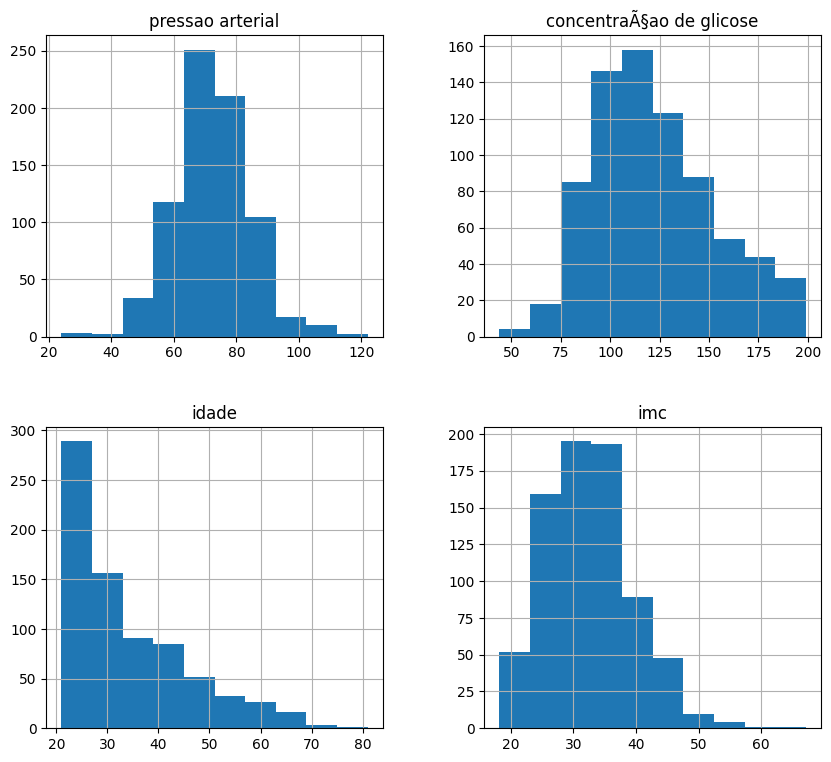

In [28]:
# plot das colunas

diabetes.hist(figsize=(10,9))

# Variância e Desvio Padrão

#### Servem para entender como os dados se distribuem dentro de um conjunto de informações

#### > Variância: como os dados se desviam da média

#### > Desvio Padrão: desvio padrão menor indica que os dados estão menos espalhados em relação à média; desvio padrão maior indica que os dados estão mais espalhados em relação à média

In [29]:
import statistics

lista1 =[0,1,2,3,3,3,4,4,4,5,5,6]
lista2 = [0,-1,-2,30,3,3,4,40,4,-50,5,6]

print(f'Média lista 1: {statistics.mean(lista1)}')
print(f'Média lista 2: {statistics.mean(lista2)}')

Média lista 1: 3.3333333333333335
Média lista 2: 3.5


In [30]:
statistics.variance(lista1)

2.9696969696969697

In [31]:
statistics.variance(lista2)

451.72727272727275

In [32]:
# desvio padrão
dp = statistics.stdev(lista2)
dp

21.253876651737507

In [33]:
m = statistics.mean(lista2)

In [34]:
m - dp, m + dp # faixa 1 desvio padrão

(-17.753876651737507, 24.753876651737507)

In [35]:
m - 2*dp, m + 2*dp  # faixa 2 desvio padrao

(-39.00775330347501, 46.00775330347501)

# Variância e Desvio Padrão no Pandas

In [36]:
diabetes3 = pd.read_excel('bases de dados/diabetes.xlsx', 'in')

In [37]:
diabetes3[['idade', 'imc']]

,idade,imc
0,50,33.6
1,31,26.6
2,32,23.3
3,21,28.1
4,33,43.1
...,...,...
763,63,32.9
764,27,36.8
765,30,26.2
766,47,30.1


In [38]:
# variancia da idade
# quanto maior o valor, mais disperso os dados estão !!!
diabetes3['idade'].var()

138.30304589037377

In [39]:
diabetes3['imc'].var()

47.955463399802895

In [40]:
# desvio padrão
diabetes3[['idade', 'imc']].std()

idade    11.760232
imc       6.924988
dtype: float64

In [41]:
# média
diabetes3[['idade', 'imc']].mean()

idade    33.240885
imc      32.457464
dtype: float64

# Análise Descritiva com Pandas

In [42]:
diabetes4 = pd.read_csv('bases de dados/diabetes.csv')

### Info

In [43]:
diabetes4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pressao arterial         733 non-null    float64
 1   concentraçao de glicose  763 non-null    float64
 2   insulina                 394 non-null    float64
 3   tipo sanguineo           723 non-null    object 
 4   idade                    768 non-null    int64  
 5   imc                      757 non-null    float64
 6   diabetico                768 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 42.1+ KB


### Describe

In [44]:
# análise estatística geral do DataFrame
diabetes4.describe()

# descrição do resultado encontrado abaixo:
# 25% das pessoas têm pressão arterial abaixo de 64
# 50% das pessoas têm pressão arterial abaixo de 72
# 75% das pessoas têm pressão arterial abaixo de 80

,pressao arterial,concentraçao de glicose,insulina,idade,imc
count,733.000000,763.000000,394.000000,768.000000,757.000000
mean,72.405184,121.686763,155.548223,33.240885,32.457464
std,12.382158,30.535641,118.775855,11.760232,6.924988
min,24.000000,44.000000,14.000000,21.000000,18.200000
25%,64.000000,99.000000,76.250000,24.000000,27.500000
50%,72.000000,117.000000,125.000000,29.000000,32.300000
75%,80.000000,141.000000,190.000000,41.000000,36.600000
max,122.000000,199.000000,846.000000,81.000000,67.100000


### Corr

In [45]:
# correlação entre as colunas numéricas, e como elas afetam umas as outras
# Quanto mais próximo de 1: correlação forte positiva - quando uma coluna aumenta a outra também aumenta
# Quanto mais próximo de -1: correlação forte negativa - quando uma coluna diminuiu a outra também diminui
# Entre -0,5 e +0,5: correlação fraca, 
# sendo 0 nenhuma correlação

In [46]:
diabetes4.corr(numeric_only=True)

,pressao arterial,concentraçao de glicose,insulina,idade,imc
pressao arterial,1.000000,0.223192,0.098272,0.330107,0.289230
concentraçao de glicose,0.223192,1.000000,0.581186,0.267136,0.232771
insulina,0.098272,0.581186,1.000000,0.220261,0.228050
idade,0.330107,0.267136,0.220261,1.000000,0.025841
imc,0.289230,0.232771,0.228050,0.025841,1.000000


### Value Counts

In [47]:
diabetes4['tipo sanguineo'].value_counts()

tipo sanguineo
A     396
O     228
B      78
AB     21
Name: count, dtype: int64

### Nulos

In [48]:
diabetes4.isna()

,pressao arterial,concentraçao de glicose,insulina,tipo sanguineo,idade,imc,diabetico
0,False,False,True,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False
764,False,False,True,False,False,False,False
765,False,False,False,False,False,False,False
766,False,False,True,True,False,False,False


In [49]:
diabetes4.isna().sum()

pressao arterial            35
concentraçao de glicose      5
insulina                   374
tipo sanguineo              45
idade                        0
imc                         11
diabetico                    0
dtype: int64

In [50]:
# porcentagem de valor nulo por coluna
diabetes4.isna().sum() / len(diabetes4)*100

pressao arterial            4.557292
concentraçao de glicose     0.651042
insulina                   48.697917
tipo sanguineo              5.859375
idade                       0.000000
imc                         1.432292
diabetico                   0.000000
dtype: float64